In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

RUNS_DIR = os.path.join('..', 'classifier_runs', 'all_ptms_model', 'cnn_gru')

runs = []  # list of dicts
all_ptm_names = set()

for run_name in sorted(os.listdir(RUNS_DIR)):
    run_path = os.path.join(RUNS_DIR, run_name)
    config_path = os.path.join(run_path, 'config.json')
    test_path = os.path.join(run_path, 'metrics_test_per_ptm.json')
    if not os.path.isfile(config_path) or not os.path.isfile(test_path):
        continue
    with open(config_path) as f:
        cfg = json.load(f)
    with open(test_path) as f:
        metrics = json.load(f)

    overall = metrics.get('overall', {})
    macro = metrics.get('macro', {})
    per_ptm = metrics.get('per_ptm', {})
    all_ptm_names.update(per_ptm.keys())

    runs.append({
        'run': run_name,
        'conv_layers': int(cfg.get('conv_layers', 0)),
        'rnn_layers': int(cfg.get('rnn_layers', 0)),
        'lr': float(cfg.get('lr', 0)),
        'ptm_embed_dim': int(cfg.get('ptm_embed_dim', 0)),
        'num_epochs': int(cfg.get('num_epochs', 0)),
        'overall': overall,
        'macro': macro,
        'per_ptm': per_ptm,
    })

ptm_names = sorted(all_ptm_names)
n_runs = len(runs)

# Build numpy arrays for quick slicing
conv_arr = np.array([r['conv_layers'] for r in runs])
rnn_arr = np.array([r['rnn_layers'] for r in runs])
lr_arr = np.array([r['lr'] for r in runs])
macro_mcc = np.array([r['macro'].get('macro_mcc', np.nan) for r in runs])
macro_f1 = np.array([r['macro'].get('macro_f1', np.nan) for r in runs])
macro_auroc = np.array([r['macro'].get('macro_auroc', np.nan) for r in runs])
macro_aupr = np.array([r['macro'].get('macro_aupr', np.nan) for r in runs])

# Per-PTM MCC matrix: [n_runs, n_ptms]
per_ptm_mcc = np.full((n_runs, len(ptm_names)), np.nan)
per_ptm_f1 = np.full((n_runs, len(ptm_names)), np.nan)
per_ptm_auroc = np.full((n_runs, len(ptm_names)), np.nan)
per_ptm_aupr = np.full((n_runs, len(ptm_names)), np.nan)
per_ptm_n = np.full((n_runs, len(ptm_names)), 0.0)

for i, r in enumerate(runs):
    for j, ptm in enumerate(ptm_names):
        pm = r['per_ptm'].get(ptm, {})
        per_ptm_mcc[i, j] = pm.get('mcc', np.nan)
        per_ptm_f1[i, j] = pm.get('f1', np.nan)
        per_ptm_auroc[i, j] = pm.get('auroc', np.nan)
        per_ptm_aupr[i, j] = pm.get('aupr', np.nan)
        per_ptm_n[i, j] = pm.get('n', 0)

print(f'Loaded {n_runs} runs with test metrics.')
print(f'PTM types found: {ptm_names}')

Loaded 7 runs with test metrics.
PTM types found: ['acet_k', 'met_r', 'phos_y', 'sumo_k']


In [3]:
# Best run by macro MCC
best_i = int(np.nanargmax(macro_mcc))
best = runs[best_i]

print('BEST RUN (by macro MCC)')
print(f"  Run          : {best['run']}")
print(f"  Conv layers  : {best['conv_layers']}")
print(f"  RNN layers   : {best['rnn_layers']}")
print(f"  LR           : {best['lr']}")
print(f"  Embed dim    : {best['ptm_embed_dim']}")
print(f"  Epochs       : {best['num_epochs']}")
print()
print('  Overall metrics:')
for k in ['mcc', 'f1', 'auroc', 'aupr']:
    print(f"    {k.upper():<6} = {best['overall'].get(k, float('nan')):.4f}")
print()
print('  Macro-averaged metrics:')
for k in ['macro_mcc', 'macro_f1', 'macro_auroc', 'macro_aupr']:
    print(f"    {k:<13} = {best['macro'].get(k, float('nan')):.4f}")
print()
print('  Per-PTM (best run):')
print(f"  {'PTM':<12} {'MCC':>8} {'F1':>8} {'AUROC':>8} {'AUPR':>8} {'N':>8}")
print(f"  {'-'*54}")
for j, ptm in enumerate(ptm_names):
    print(f"  {ptm:<12} {per_ptm_mcc[best_i,j]:8.4f} {per_ptm_f1[best_i,j]:8.4f} "
          f"{per_ptm_auroc[best_i,j]:8.4f} {per_ptm_aupr[best_i,j]:8.4f} {int(per_ptm_n[best_i,j]):8d}")

BEST RUN (by macro MCC)
  Run          : 20260327_225704
  Conv layers  : 1
  RNN layers   : 2
  LR           : 0.0005
  Embed dim    : 32
  Epochs       : 35

  Overall metrics:
    MCC    = 0.4886
    F1     = 0.6765
    AUROC  = 0.8294
    AUPR   = 0.7187

  Macro-averaged metrics:
    macro_mcc     = 0.4163
    macro_f1      = 0.6117
    macro_auroc   = 0.7973
    macro_aupr    = 0.6439

  Per-PTM (best run):
  PTM               MCC       F1    AUROC     AUPR        N
  ------------------------------------------------------
  acet_k         0.4560   0.7474   0.8040   0.7866     5559
  met_r          0.3843   0.5146   0.7701   0.5411     4449
  phos_y         0.3661   0.4744   0.8029   0.4963     5814
  sumo_k         0.4588   0.7106   0.8122   0.7515     8615


In [4]:
def grouped_bar(arr_key, arr_vals, metric_vals, xlabel, title, color):
    """Bar chart: mean +/- std of metric_vals grouped by unique values of arr_vals."""
    uniq = np.unique(arr_vals)
    means, stds, counts = [], [], []
    for u in uniq:
        mask = arr_vals == u
        v = metric_vals[mask]
        v = v[~np.isnan(v)]
        means.append(np.mean(v) if len(v) else 0)
        stds.append(np.std(v) if len(v) else 0)
        counts.append(len(v))
    means, stds = np.array(means), np.array(stds)

    fig, ax = plt.subplots(figsize=(6, 4))
    labels = [str(u) for u in uniq]
    ax.bar(labels, means, yerr=stds, capsize=5, color=color, edgecolor='black', alpha=0.85)
    for i, (m, s, c) in enumerate(zip(means, stds, counts)):
        ax.text(i, m + s + 0.005, f'n={c}', ha='center', fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Macro MCC')
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

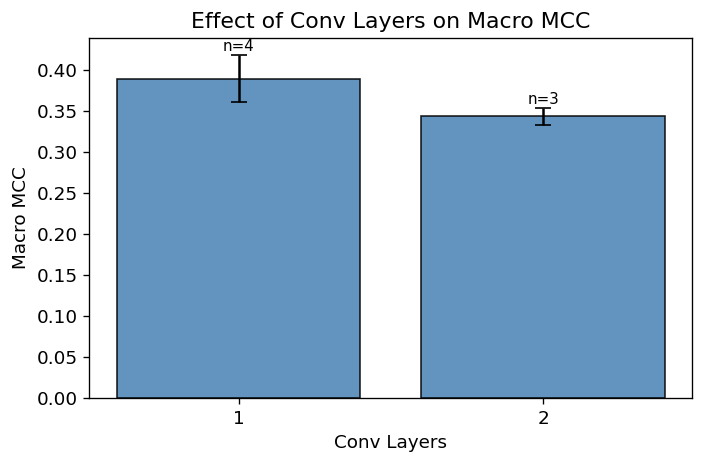

In [5]:
grouped_bar('conv', conv_arr, macro_mcc, 'Conv Layers',
            'Effect of Conv Layers on Macro MCC', 'steelblue')

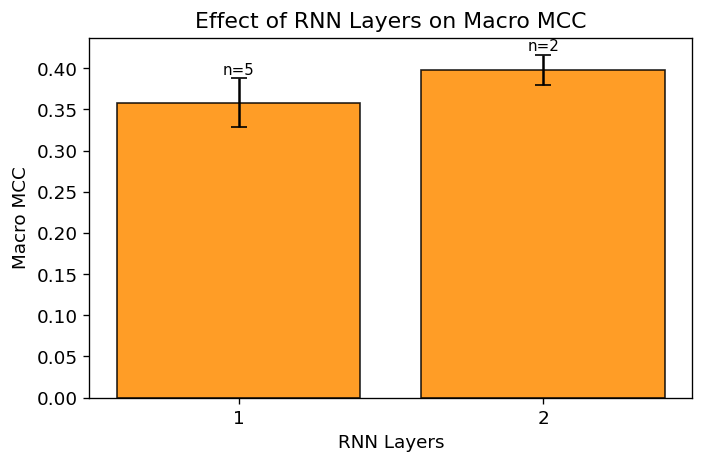

In [6]:
grouped_bar('rnn', rnn_arr, macro_mcc, 'RNN Layers',
            'Effect of RNN Layers on Macro MCC', 'darkorange')

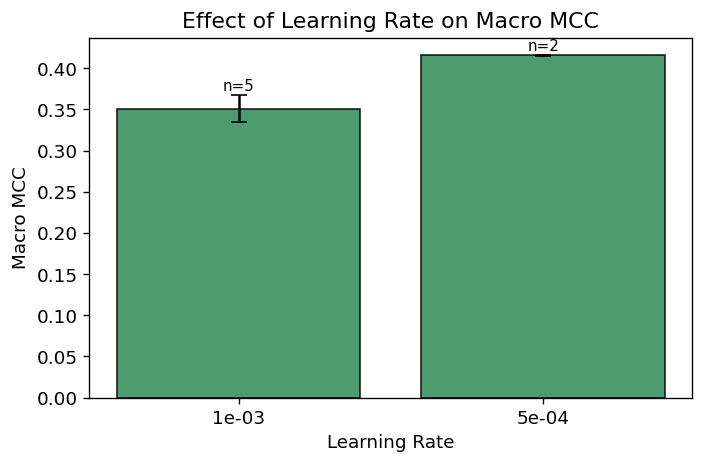

In [7]:
# Format LR as strings for grouping
lr_labels = np.array([f'{v:.0e}' for v in lr_arr])
uniq_lr = np.unique(lr_labels)
means, stds, counts = [], [], []
for u in uniq_lr:
    mask = lr_labels == u
    v = macro_mcc[mask]
    v = v[~np.isnan(v)]
    means.append(np.mean(v) if len(v) else 0)
    stds.append(np.std(v) if len(v) else 0)
    counts.append(len(v))
means, stds = np.array(means), np.array(stds)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(uniq_lr, means, yerr=stds, capsize=5, color='seagreen', edgecolor='black', alpha=0.85)
for i, (m, s, c) in enumerate(zip(means, stds, counts)):
    ax.text(i, m + s + 0.005, f'n={c}', ha='center', fontsize=9)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Macro MCC')
ax.set_title('Effect of Learning Rate on Macro MCC')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

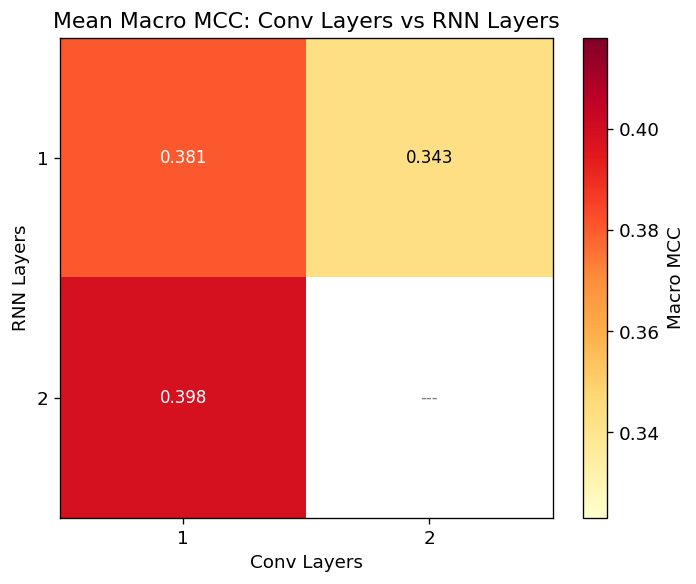

In [8]:
# Heatmap: Conv layers vs RNN layers -> macro MCC
conv_uniq = np.sort(np.unique(conv_arr))
rnn_uniq = np.sort(np.unique(rnn_arr))
grid = np.full((len(rnn_uniq), len(conv_uniq)), np.nan)

for ri, rv in enumerate(rnn_uniq):
    for ci, cv in enumerate(conv_uniq):
        mask = (conv_arr == cv) & (rnn_arr == rv)
        v = macro_mcc[mask]
        v = v[~np.isnan(v)]
        if len(v):
            grid[ri, ci] = np.mean(v)

valid = grid[~np.isnan(grid)]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(grid, cmap='YlOrRd', aspect='auto',
               vmin=valid.min() - 0.02 if len(valid) else 0,
               vmax=valid.max() + 0.02 if len(valid) else 1)
ax.set_xticks(range(len(conv_uniq)))
ax.set_xticklabels([int(c) for c in conv_uniq])
ax.set_yticks(range(len(rnn_uniq)))
ax.set_yticklabels([int(r) for r in rnn_uniq])
ax.set_xlabel('Conv Layers')
ax.set_ylabel('RNN Layers')
ax.set_title('Mean Macro MCC: Conv Layers vs RNN Layers')

mean_val = np.nanmean(grid) if len(valid) else 0
for ri in range(len(rnn_uniq)):
    for ci in range(len(conv_uniq)):
        val = grid[ri, ci]
        if not np.isnan(val):
            ax.text(ci, ri, f'{val:.3f}', ha='center', va='center', fontsize=10,
                    color='white' if val > mean_val else 'black')
        else:
            ax.text(ci, ri, '---', ha='center', va='center', fontsize=10, color='grey')

fig.colorbar(im, ax=ax, label='Macro MCC')
plt.tight_layout()
plt.show()

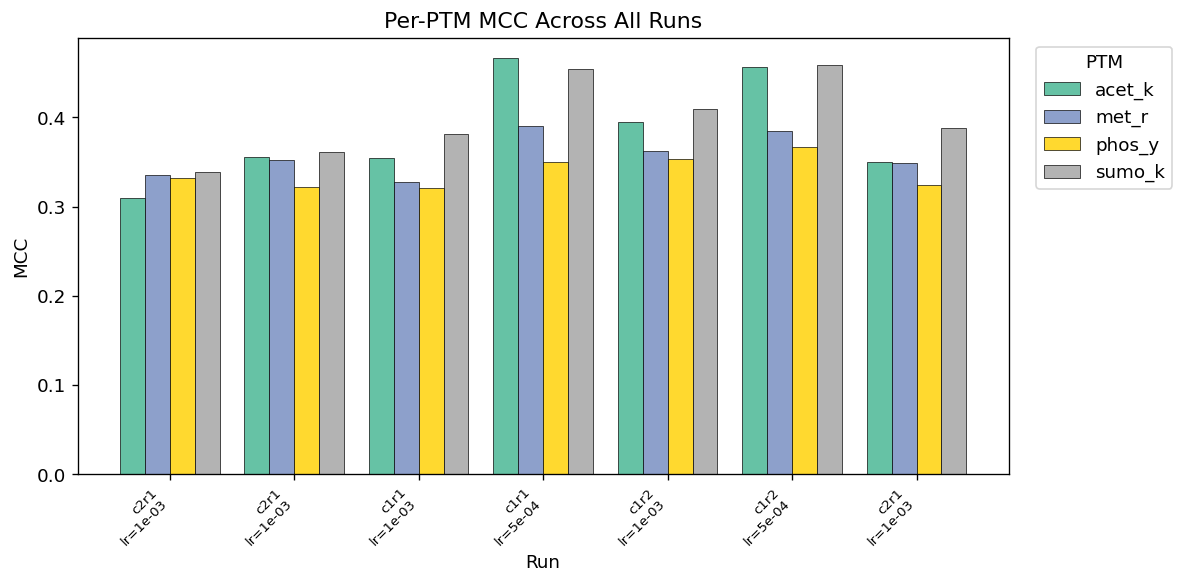

In [9]:
# Per-PTM MCC across all runs (grouped bar chart)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_runs)
n_ptm = len(ptm_names)
width = 0.8 / max(n_ptm, 1)
colors = plt.cm.Set2(np.linspace(0, 1, n_ptm))

for j, ptm in enumerate(ptm_names):
    vals = np.where(np.isnan(per_ptm_mcc[:, j]), 0, per_ptm_mcc[:, j])
    ax.bar(x + j * width, vals, width, label=ptm, color=colors[j], edgecolor='black', linewidth=0.4)

ax.set_xlabel('Run')
ax.set_ylabel('MCC')
ax.set_title('Per-PTM MCC Across All Runs')
ax.set_xticks(x + width * (n_ptm - 1) / 2)
run_labels = [f"c{r['conv_layers']}r{r['rnn_layers']}\nlr={r['lr']:.0e}" for r in runs]
ax.set_xticklabels(run_labels, fontsize=8, rotation=45, ha='right')
ax.legend(title='PTM', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [10]:
# Summary table sorted by macro MCC (printed, no pandas)
order = np.argsort(macro_mcc)[::-1]  # descending

header = f"{'Rank':>4}  {'Run':<20} {'Conv':>5} {'RNN':>5} {'LR':>10} {'Epochs':>7}  {'macro_MCC':>10} {'macro_F1':>9} {'macro_AUROC':>12} {'macro_AUPR':>11}"
print(header)
print('-' * len(header))
for rank, idx in enumerate(order, 1):
    r = runs[idx]
    def fmt(v):
        return f'{v:.4f}' if not np.isnan(v) else 'N/A'
    print(f"{rank:>4}  {r['run']:<20} {r['conv_layers']:>5} {r['rnn_layers']:>5} {r['lr']:>10.1e} {r['num_epochs']:>7}  "
          f"{fmt(macro_mcc[idx]):>10} {fmt(macro_f1[idx]):>9} {fmt(macro_auroc[idx]):>12} {fmt(macro_aupr[idx]):>11}")

Rank  Run                   Conv   RNN         LR  Epochs   macro_MCC  macro_F1  macro_AUROC  macro_AUPR
--------------------------------------------------------------------------------------------------------
   1  20260327_225704          1     2    5.0e-04      35      0.4163    0.6117       0.7973      0.6439
   2  20260327_204221          1     1    5.0e-04      35      0.4152    0.6002       0.7973      0.6425
   3  20260327_215041          1     2    1.0e-03      35      0.3798    0.6000       0.7734      0.6072
   4  20260328_022741          2     1    1.0e-03      35      0.3527    0.5720       0.7504      0.5861
   5  20260325_225221          2     1    1.0e-03      30      0.3478    0.5605       0.7530      0.5815
   6  20260327_193520          1     1    1.0e-03      35      0.3459    0.5698       0.7532      0.5762
   7  20260325_214941          2     1    1.0e-03       3      0.3288    0.5698       0.7489      0.5802
